# Regularized Estimators and scikit-learn Comparison

This notebook demonstrates the new regularized estimator API in `pyensmallen`.
When `alpha > 0`, the linear, logistic, and Poisson estimator classes switch
from unconstrained `L_BFGS` to exact Frank-Wolfe optimization over either an
L2 ball (`l1_ratio=0.0`) or an L1 ball (`l1_ratio=1.0`).

The second half of the notebook compares `pyensmallen` with scikit-learn on a
moderate `p` versus `n` linear problem and plots out-of-sample MSE over a grid
of regularization strengths.

In [1]:
import os
import sys
import warnings

candidate_roots = [
    os.getcwd(),
    os.path.abspath(".."),
    os.path.abspath(os.path.join("..", "..")),
]
repo_root = next(
    path
    for path in candidate_roots
    if os.path.exists(os.path.join(path, "pyensmallen", "__init__.py"))
)
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

sys.meta_path = [
    finder
    for finder in sys.meta_path
    if getattr(finder.__class__, "__module__", "") != "_pyensmallen_editable_loader"
]

warnings.filterwarnings("ignore", message=".*joblib will operate in serial mode.*")
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.special import expit
from sklearn.linear_model import Lasso, LogisticRegression as SkLogit, PoissonRegressor, Ridge
from sklearn.metrics import (
    accuracy_score,
    log_loss,
    mean_poisson_deviance,
    mean_squared_error,
)

import pyensmallen as pe

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(12345)

## Shared regularization API across estimators

All three estimator classes accept the same regularization arguments:

- `alpha=0.0` keeps the unregularized `L_BFGS` fit
- `alpha>0, l1_ratio=0.0` uses Frank-Wolfe over an L2 ball
- `alpha>0, l1_ratio=1.0` uses Frank-Wolfe over an L1 ball

Below we fit one regularized example for each estimator class and compare it
with the closest scikit-learn counterpart using a common metric.

In [2]:
rows = []

# Linear regression: compare against scikit-learn Lasso.
n_linear, p_linear = 600, 12
X_linear = rng.normal(size=(n_linear, p_linear))
beta_linear = np.zeros(p_linear)
beta_linear[:4] = np.array([1.0, -0.75, 0.5, 0.25])
y_linear = 0.4 + X_linear @ beta_linear + rng.normal(scale=0.7, size=n_linear)

alpha_linear = 0.5
py_linear = pe.LinearRegression(alpha=alpha_linear, l1_ratio=1.0).fit(X_linear, y_linear)
sk_linear = Lasso(alpha=alpha_linear, fit_intercept=True, max_iter=10000, tol=1e-6).fit(X_linear, y_linear)

for library, model in [("pyensmallen", py_linear), ("scikit-learn", sk_linear)]:
    rows.append(
        {
            "estimator": "LinearRegression",
            "library": library,
            "regularization": "L1",
            "metric": "train MSE",
            "value": mean_squared_error(y_linear, model.predict(X_linear)),
            "coef_norm": np.linalg.norm(model.coef_, 1),
            "optimizer": getattr(model, "optimizer_name_", "coordinate descent"),
        }
    )

# Logistic regression: compare against scikit-learn's l2-regularized logit.
X_logit = rng.normal(size=(800, 3))
eta = -0.3 + X_logit @ np.array([1.2, -0.9, 0.6])
p_logit = expit(eta)
y_logit = rng.binomial(1, p_logit)

alpha_logit = 0.25
py_logit = pe.LogisticRegression(alpha=alpha_logit, l1_ratio=0.0).fit(X_logit, y_logit)
sk_logit = SkLogit(C=1.0 / alpha_logit, solver="lbfgs", fit_intercept=True, max_iter=5000).fit(X_logit, y_logit)

for library, model, probs in [
    ("pyensmallen", py_logit, py_logit.predict_proba(X_logit)[:, 1]),
    ("scikit-learn", sk_logit, sk_logit.predict_proba(X_logit)[:, 1]),
]:
    rows.append(
        {
            "estimator": "LogisticRegression",
            "library": library,
            "regularization": "L2",
            "metric": "log loss",
            "value": log_loss(y_logit, probs),
            "coef_norm": np.linalg.norm(model.coef_),
            "optimizer": getattr(model, "optimizer_name_", "lbfgs"),
        }
    )
    rows.append(
        {
            "estimator": "LogisticRegression",
            "library": library,
            "regularization": "L2",
            "metric": "accuracy",
            "value": accuracy_score(y_logit, (probs >= 0.5).astype(int)),
            "coef_norm": np.linalg.norm(model.coef_),
            "optimizer": getattr(model, "optimizer_name_", "lbfgs"),
        }
    )

# Poisson regression: compare against scikit-learn PoissonRegressor.
X_pois = rng.normal(size=(800, 3))
mu = np.exp(0.2 + X_pois @ np.array([0.3, -0.2, 0.15]))
y_pois = rng.poisson(mu)

alpha_pois = 0.25
py_pois = pe.PoissonRegression(alpha=alpha_pois, l1_ratio=0.0).fit(X_pois, y_pois)
sk_pois = PoissonRegressor(alpha=alpha_pois, fit_intercept=True, max_iter=5000).fit(X_pois, y_pois)

for library, model, preds in [
    ("pyensmallen", py_pois, py_pois.predict(X_pois)),
    ("scikit-learn", sk_pois, sk_pois.predict(X_pois)),
]:
    rows.append(
        {
            "estimator": "PoissonRegression",
            "library": library,
            "regularization": "L2",
            "metric": "mean Poisson deviance",
            "value": mean_poisson_deviance(y_pois, np.clip(preds, 1e-8, None)),
            "coef_norm": np.linalg.norm(model.coef_),
            "optimizer": getattr(model, "optimizer_name_", "lbfgs"),
        }
    )

shared_api_results = pd.DataFrame(rows)
shared_api_results

,estimator,library,regularization,metric,value,coef_norm,optimizer
0,LinearRegression,pyensmallen,L1,train MSE,0.660204,1.828547,FrankWolfe
1,LinearRegression,scikit-learn,L1,train MSE,1.336264,0.748089,coordinate descent
2,LogisticRegression,pyensmallen,L2,log loss,0.498372,1.621752,FrankWolfe
3,LogisticRegression,pyensmallen,L2,accuracy,0.765000,1.621752,FrankWolfe
4,LogisticRegression,scikit-learn,L2,log loss,0.498372,1.618707,lbfgs
5,LogisticRegression,scikit-learn,L2,accuracy,0.765000,1.618707,lbfgs
6,PoissonRegression,pyensmallen,L2,mean Poisson deviance,1.174252,0.432143,FrankWolfe
7,PoissonRegression,scikit-learn,L2,mean Poisson deviance,1.180530,0.359993,lbfgs


## Moderate `p` versus `n`: out-of-sample MSE path

We now generate a sparse linear problem with `p=120` features and only
`n=200` training observations. The goal is not to numerically match
scikit-learn's penalty parameterization exactly. Instead, the same grid of
regularization strengths is used in both libraries so we can compare the shape
of the MSE path and the best achievable out-of-sample error.

Two comparisons are shown:

- `pyensmallen` L2-constrained fit vs scikit-learn Ridge
- `pyensmallen` L1-constrained fit vs scikit-learn Lasso

In [3]:
n_train, n_test, p = 200, 2000, 120
n_active = 12
alpha_grid = np.logspace(-2, 1.2, 12)

X_train = rng.normal(size=(n_train, p))
X_test = rng.normal(size=(n_test, p))

beta_true = np.zeros(p)
active = rng.choice(p, size=n_active, replace=False)
beta_true[active] = rng.normal(loc=0.0, scale=1.5, size=n_active)
intercept_true = 0.5

y_train = intercept_true + X_train @ beta_true + rng.normal(scale=1.0, size=n_train)
y_test = intercept_true + X_test @ beta_true + rng.normal(scale=1.0, size=n_test)

print(f"train shape: {X_train.shape}, test shape: {X_test.shape}")
print(f"nonzero coefficients: {n_active}")

train shape: (200, 120), test shape: (2000, 120)
nonzero coefficients: 12


In [4]:
rows = []

for alpha in alpha_grid:
    py_l2 = pe.LinearRegression(alpha=float(alpha), l1_ratio=0.0).fit(X_train, y_train)
    py_l1 = pe.LinearRegression(alpha=float(alpha), l1_ratio=1.0).fit(X_train, y_train)
    sk_ridge = Ridge(alpha=float(alpha), fit_intercept=True).fit(X_train, y_train)
    sk_lasso = Lasso(alpha=float(alpha), fit_intercept=True, max_iter=10000, tol=1e-6).fit(X_train, y_train)

    for model_name, model, penalty in [
        ("pyensmallen-l2", py_l2, "l2"),
        ("pyensmallen-l1", py_l1, "l1"),
        ("sklearn-ridge", sk_ridge, "l2"),
        ("sklearn-lasso", sk_lasso, "l1"),
    ]:
        rows.append(
            {
                "alpha": alpha,
                "model": model_name,
                "penalty": penalty,
                "train_mse": mean_squared_error(y_train, model.predict(X_train)),
                "test_mse": mean_squared_error(y_test, model.predict(X_test)),
                "coef_l1": np.linalg.norm(model.coef_, 1),
                "coef_l2": np.linalg.norm(model.coef_, 2),
            }
        )

results = pd.DataFrame(rows)
results.head()

,alpha,model,penalty,train_mse,test_mse,coef_l1,coef_l2
0,0.010000,pyensmallen-l2,l2,0.300465,2.424340,26.118816,5.381626
1,0.010000,pyensmallen-l1,l1,0.578212,1.615896,19.914086,5.318775
2,0.010000,sklearn-ridge,l2,0.297860,2.427721,26.179356,5.403925
3,0.010000,sklearn-lasso,l1,0.331483,1.656856,22.333471,5.330794
4,0.019539,pyensmallen-l2,l2,0.298860,2.423294,26.105470,5.379762


In [5]:
best_by_model = (
    results.sort_values("test_mse")
    .groupby("model", as_index=False)
    .first()[["model", "alpha", "train_mse", "test_mse", "coef_l1", "coef_l2"]]
    .sort_values("test_mse")
)
best_by_model

,model,alpha,train_mse,test_mse,coef_l1,coef_l2
2,sklearn-lasso,0.074598,0.662303,1.202322,17.055005,5.084258
0,pyensmallen-l1,0.010000,0.578212,1.615896,19.914086,5.318775
3,sklearn-ridge,1.087336,0.300220,2.418005,25.950701,5.322411
1,pyensmallen-l2,0.145759,0.298654,2.419524,26.050077,5.358361


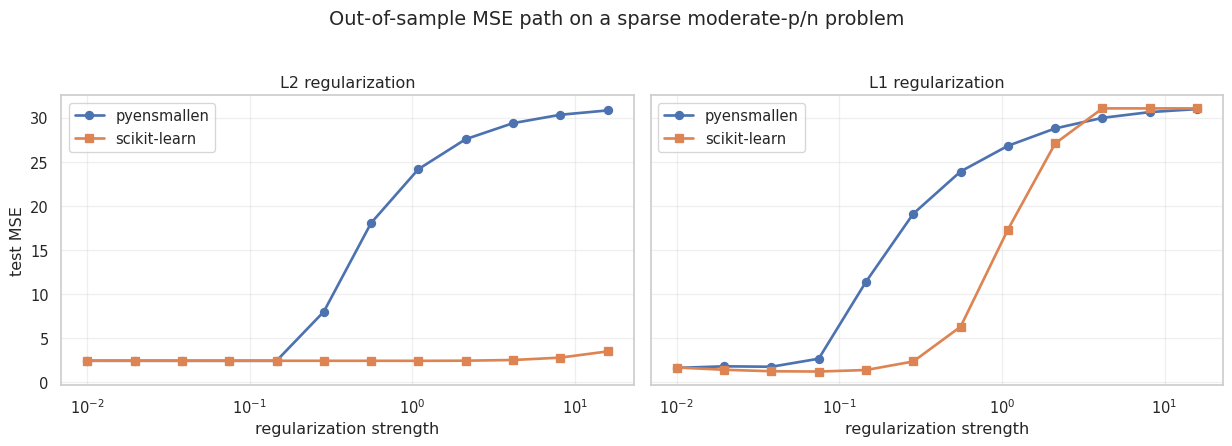

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

curve_specs = [
    ("l2", [("pyensmallen-l2", "pyensmallen", "o"), ("sklearn-ridge", "scikit-learn", "s")], "L2 regularization"),
    ("l1", [("pyensmallen-l1", "pyensmallen", "o"), ("sklearn-lasso", "scikit-learn", "s")], "L1 regularization"),
]

for ax, (penalty, curves, title) in zip(axes, curve_specs):
    panel = results.loc[results["penalty"] == penalty]
    for model_name, label, marker in curves:
        curve = panel.loc[panel["model"] == model_name].sort_values("alpha")
        ax.plot(
            curve["alpha"],
            curve["test_mse"],
            marker=marker,
            linewidth=2,
            label=label,
        )
    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("regularization strength")
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("test MSE")
axes[0].legend(frameon=True)
axes[1].legend(frameon=True)
fig.suptitle("Out-of-sample MSE path on a sparse moderate-p/n problem", y=1.03)
fig.tight_layout()
plt.show()

## Takeaways

- The same estimator interface now covers unregularized and exact constrained regularized fits.
- The regularized `pyensmallen` fits quietly switch to Frank-Wolfe on the backend.
- On this sparse moderate-`p` problem, the L1 path is much more competitive than the L2 path, which is what we would expect.
- The MSE curves have the same broad shape as the scikit-learn baselines, even though the two libraries do not use identical regularization parameterizations.